# T1 Analysis



<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;">Import Libraries</h2>
</div>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path
from scipy.optimize import curve_fit

<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;"> General Helpful Functions</h2>
</div>

In [2]:
def load_run(run_folder):
    data = np.load(run_folder / "t1_mwref_data.npz")
    with open(run_folder / "metadata.json") as f:
        metadata = json.load(f)

    skip_keys = {"experiment_id", "timestamp"}  # don't need these
    run = {k: v for k, v in metadata.items() if k not in skip_keys}

    run["delay_us"] = data["delay_us"]
    run["signal1"] = data["signal1"]
    run["signal2"] = data["signal2"]
    run["reference1"] = data["reference1"]
    run["reference2"] = data["reference2"]
    run["run_folder"] = run_folder
    return run

def load_all_runs(parent_dir):
    parent_dir = Path(parent_dir)
    runs = {}
    for run_folder in sorted(parent_dir.iterdir()):
        if not run_folder.is_dir():
            continue
        if not (run_folder / "t1_mwref_data.npz").exists():  # skip crashed/empty runs
            continue
        run_number = int(run_folder.name.split("_")[-1])
        runs[run_number] = load_run(run_folder)
    return runs

def decay(t, A, T1):
    return A * np.exp(-t / T1)  # S1 - S2 model

<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;">Load Data</h2>
</div>

In [24]:
parent_dir = "/Volumes/hlab-nas/Data/DefectMsmts/Data/Albania/T1_MWref"
runs = load_all_runs(parent_dir)
print(list(runs.keys()))

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]


<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;">Plotting</h2>
</div>

In [25]:
run_number = 25
run = runs[run_number]

t = run["delay_us"]
s1, s2 = run["signal1"], run["signal2"]
r1, r2 = run["reference1"], run["reference2"]
run_name = run["run_folder"].name

<div style="background-color:#2196F3; padding:8px 14px; border-radius:4px;">
<h3 style="color:black; margin:0;"> Plot Raw Data</h3>
</div>


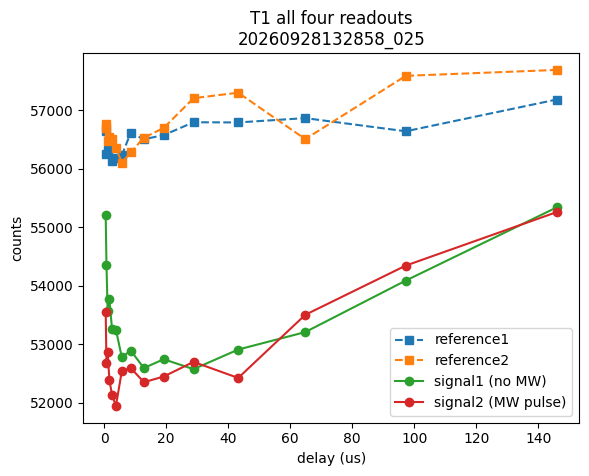

In [26]:
plt.plot(t, r1, 's--', label='reference1')
plt.plot(t, r2, 's--', label='reference2')
plt.plot(t, s1, 'o-', label='signal1 (no MW)')
plt.plot(t, s2, 'o-', label='signal2 (MW pulse)')

plt.xlabel('delay (us)')
plt.ylabel('counts')
plt.title(f"T1 all four readouts\n{run_name}")
plt.legend()
plt.show()

<div style="background-color:#2196F3; padding:8px 14px; border-radius:4px;">
<h3 style="color:black; margin:0;"> Plot T1 Signal</h3>
</div>


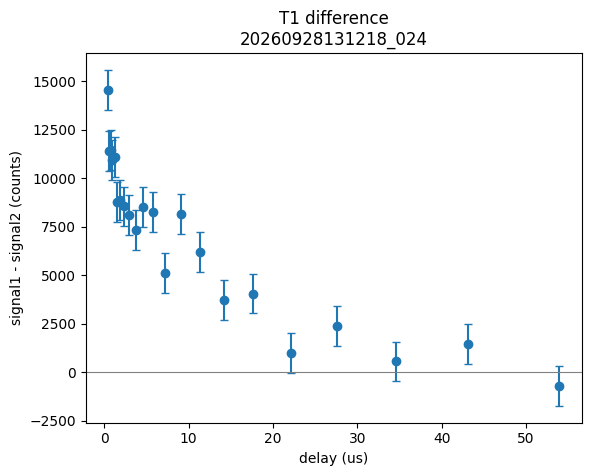

In [21]:
diff = s1 - s2
err = np.sqrt(s1 + s2)  # photon noise on the difference

plt.errorbar(t, diff, yerr=err, fmt='o', capsize=3)
plt.axhline(0, color='gray', lw=0.8)
plt.xlabel('delay (us)')
plt.ylabel('signal1 - signal2 (counts)')
plt.title(f"T1 difference\n{run_name}")
plt.show()

<div style="background-color:#2196F3; padding:8px 14px; border-radius:4px;">
<h3 style="color:black; margin:0;"> Plot Fit</h3>
</div>


A  = 11600 ± 419 counts
T1 = 13.7 ± 1.5 us


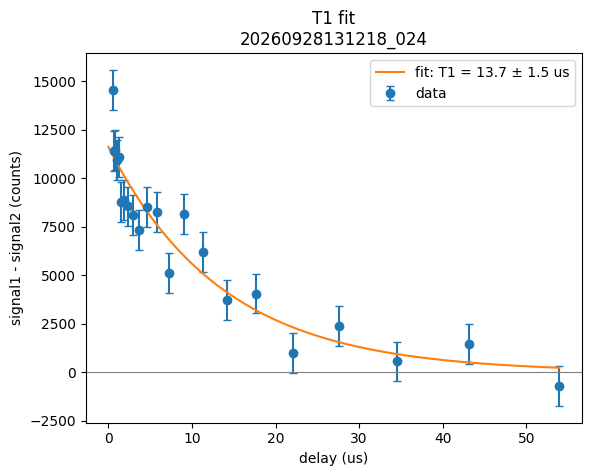

In [22]:
popt, pcov = curve_fit(decay, t, diff, p0=[diff.max(), 10], sigma=err, absolute_sigma=True)
perr = np.sqrt(np.diag(pcov))
print(f"A  = {popt[0]:.0f} ± {perr[0]:.0f} counts")
print(f"T1 = {popt[1]:.1f} ± {perr[1]:.1f} us")

tt = np.linspace(0, t.max(), 500)
plt.errorbar(t, diff, yerr=err, fmt='o', capsize=3, label='data')
plt.plot(tt, decay(tt, *popt), '-', label=f'fit: T1 = {popt[1]:.1f} ± {perr[1]:.1f} us')
plt.axhline(0, color='gray', lw=0.8)
plt.xlabel('delay (us)')
plt.ylabel('signal1 - signal2 (counts)')
plt.title(f"T1 fit\n{run_name}")
plt.legend()
plt.show()